# Modified wavenumber: what a difference scheme does to a wave

Companion to [Numerical methods](../foundations/numerical-methods.md) and
[Finite volume](../fluids/cfd/finite-volume.md).

"Second-order accurate" is an asymptotic statement about $\Delta x \to 0$. It says
nothing about the mesh you can afford. **Modified wavenumber analysis** answers the
practical question instead: for a wave resolved by $N$ points, how badly does this
scheme get its speed and amplitude wrong?

Substituting $\phi_j = e^{ikx_j}$ into a difference formula gives an effective
wavenumber $k'$ in place of $k$:

$$\frac{\partial \phi}{\partial x} \;\longrightarrow\; i k' \phi,
\qquad k' \ne k$$

- $\mathrm{Re}(k')$ differing from $k$ is **dispersion** — the wave travels at the
  wrong speed.
- $\mathrm{Im}(k') \ne 0$ is **dissipation** — the wave decays.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.figsize": (11, 3.6), "figure.dpi": 110,
    "axes.grid": True, "grid.alpha": 0.25, "font.size": 9,
})

# kh from 0 to pi; kh = pi is the 2-point (grid-scale) wave
kh = np.linspace(1e-6, np.pi, 600)

## Modified wavenumbers

For $\partial\phi/\partial x$ with $\theta = k\,\Delta x$:

| Scheme | $k'\Delta x$ |
|---|---|
| 2nd-order central | $\sin\theta$ |
| 4th-order central | $\tfrac{4}{3}\sin\theta - \tfrac{1}{6}\sin 2\theta$ |
| 6th-order central | $\tfrac{3}{2}\sin\theta - \tfrac{3}{10}\sin 2\theta + \tfrac{1}{30}\sin 3\theta$ |
| 1st-order upwind | $\sin\theta + i(1-\cos\theta)$ |
| Spectral | $\theta$ (exact) |

The central schemes are purely real — no dissipation, all error in phase. Upwind carries
an imaginary part, which is the numerical diffusion made explicit.

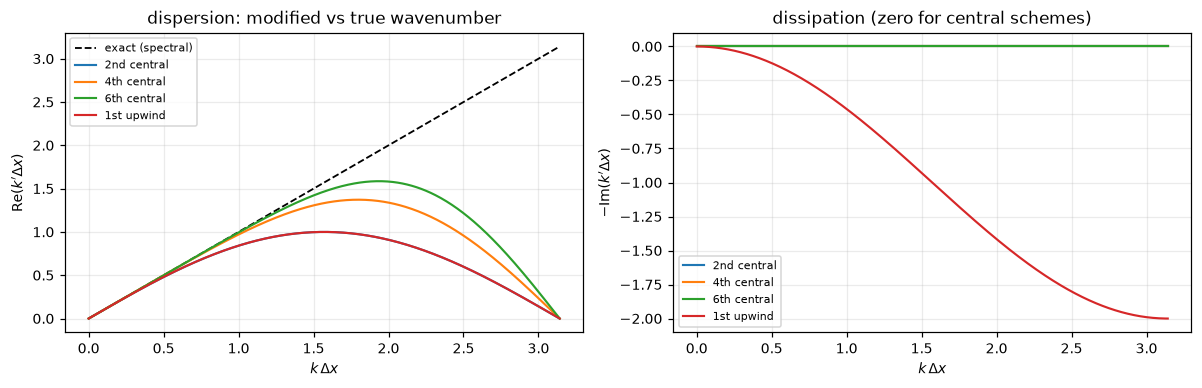

In [2]:
schemes = {
    "2nd central":  np.sin(kh),
    "4th central":  (4/3) * np.sin(kh) - (1/6) * np.sin(2*kh),
    "6th central":  (3/2) * np.sin(kh) - (3/10) * np.sin(2*kh) + (1/30) * np.sin(3*kh),
    "1st upwind":   np.sin(kh) + 1j * (1 - np.cos(kh)),
}

fig, ax = plt.subplots(1, 2)

ax[0].plot(kh, kh, "k--", lw=1.2, label="exact (spectral)")
for name, kp in schemes.items():
    ax[0].plot(kh, np.real(kp), lw=1.4, label=name)
ax[0].set_xlabel(r"$k\,\Delta x$"); ax[0].set_ylabel(r"Re$(k'\Delta x)$")
ax[0].set_title("dispersion: modified vs true wavenumber")
ax[0].legend(fontsize=7)

for name, kp in schemes.items():
    ax[1].plot(kh, -np.imag(kp), lw=1.4, label=name)
ax[1].set_xlabel(r"$k\,\Delta x$"); ax[1].set_ylabel(r"$-$Im$(k'\Delta x)$")
ax[1].set_title("dissipation (zero for central schemes)")
ax[1].legend(fontsize=7)

plt.tight_layout(); plt.show()

Every scheme tracks the diagonal at small $k\Delta x$ and falls away from it as the
wave gets shorter. **Every central scheme returns $k' = 0$ at $k\Delta x = \pi$**:
the grid-scale 2-point wave has zero computed derivative, so it is invisible to the
convection term and never advects. That mode is the origin of odd–even decoupling.

The upwind panel shows why it is stable: the imaginary part is a damping that is largest
exactly for the shortest waves.

## Points per wavelength: the number that actually sizes the grid

Formal order is asymptotic. The usable question is how many points per wavelength a scheme
needs to keep phase error under a chosen tolerance.

With $N = 2\pi/(k\Delta x)$ points per wavelength, the phase error after the wave
travels one wavelength is $2\pi\,|k' - k|/k$.

In [3]:
def points_per_wavelength(kprime_fn, tol):
    """Smallest N (points per wavelength) with relative phase error <= tol."""
    for N in range(2, 20001):
        th = 2 * np.pi / N
        err = abs(np.real(kprime_fn(th)) - th) / th
        if err <= tol:
            return N
    return None

fns = {
    "2nd central": lambda t: np.sin(t),
    "4th central": lambda t: (4/3)*np.sin(t) - (1/6)*np.sin(2*t),
    "6th central": lambda t: (3/2)*np.sin(t) - (3/10)*np.sin(2*t) + (1/30)*np.sin(3*t),
    "1st upwind":  lambda t: np.sin(t),        # same real part as 2nd central
}

tols = [0.10, 0.01, 0.001]
print(f"{'scheme':14s}" + "".join(f"{f'{100*t:g}% phase err':>18}" for t in tols))
for name, fn in fns.items():
    print(f"{name:14s}" + "".join(f"{str(points_per_wavelength(fn, t)):>18}" for t in tols))

scheme             10% phase err      1% phase err    0.1% phase err
2nd central                    8                26                82
4th central                    5                 9                16
6th central                    4                 6                 9
1st upwind                     8                26                82


This is the table worth carrying around. To hold phase error to **1%**, a second-order
scheme needs **26 points per wavelength**; a sixth-order scheme needs **6**.

In 3D that ratio cubes: $(26/6)^3 \approx 80\times$ the cells for the same fidelity.
The high-order scheme costs more per point and needs a wider stencil — but not sixteen
times more, which is the entire argument for high-order methods in wave-dominated problems
like acoustics, [LES](../fluids/turbulence/les.md), and computational aeroacoustics.

In [4]:
# How far a wave travels before it is a quarter-wavelength out of phase
print(f"{'scheme':14s}{'N=8':>12}{'N=16':>12}{'N=32':>12}   (wavelengths travelled)")
for name, fn in fns.items():
    row = f"{name:14s}"
    for N in (8, 16, 32):
        th = 2 * np.pi / N
        rel = abs(np.real(fn(th)) - th) / th
        row += f"{(0.25 / rel if rel > 0 else np.inf):12.1f}"
    print(row + "")

scheme                 N=8        N=16        N=32   (wavelengths travelled)
2nd central            2.5         9.8        39.0
4th central           21.2       321.2      5069.1
6th central          168.1      9834.1    615381.7
1st upwind             2.5         9.8        39.0


At 8 points per wavelength a second-order scheme loses a quarter wavelength of phase after
travelling only 2.5 wavelengths. A sixth-order scheme survives about 170, and at 16 points
nearly 10,000. For a short domain
it does not matter; for a long propagation — an acoustic wave crossing a mesh, a vortex
convecting downstream — it decides whether the answer means anything.

## The modified equation, as a cross-check

The same information, read as extra physics the scheme has silently added. For first-order
upwind on $\phi_t + u\phi_x = 0$:

$$\phi_t + u\phi_x = \underbrace{\frac{u\,\Delta x}{2}(1 - c)\,\phi_{xx}}_{\text{numerical diffusion}} + O(\Delta x^2)$$

with $c$ the CFL number. That coefficient is a number you can compare against the
physical viscosity — which is the practical version of the whole analysis.

In [5]:
rho, u, mu = 1.2, 20.0, 1.8e-5
print(f"{'dx (m)':>10}{'CFL':>7}{'numerical nu':>16}{'physical nu':>14}{'ratio':>10}")
nu_phys = mu / rho
for dx in (1e-1, 1e-2, 1e-3, 1e-4):
    for c in (0.5,):
        nu_num = u * dx / 2.0 * (1 - c)
        print(f"{dx:10.0e}{c:7.1f}{nu_num:16.3e}{nu_phys:14.3e}{nu_num/nu_phys:10.0f}")

    dx (m)    CFL    numerical nu   physical nu     ratio
     1e-01    0.5       5.000e-01     1.500e-05     33333
     1e-02    0.5       5.000e-02     1.500e-05      3333
     1e-03    0.5       5.000e-03     1.500e-05       333
     1e-04    0.5       5.000e-04     1.500e-05        33


Even at 0.1 mm cells and CFL 0.5, first-order upwind adds about thirty times the physical
kinematic viscosity of air — and at a more realistic 1 mm, three hundred times. The simulation is converged, stable, smooth — and resolving the
scheme rather than the flow.

## Takeaways

1. **Order is asymptotic; points-per-wavelength is operational.** Size grids on the second.
2. **Central schemes are dispersive, upwind schemes are dissipative.** Wiggles behind a
   front and a smeared front are the same error budget spent differently.
3. **The grid-scale mode is invisible to every central scheme**, which is why odd–even
   decoupling exists and why pressure–velocity coupling needs
   [Rhie–Chow](../fluids/incompressible.md).
4. **Compare numerical diffusion against physical viscosity**, in units. It converts "this
   scheme is too diffusive" into a number.

## Connections

- [Numerical methods](../foundations/numerical-methods.md) — truncation error, modified equations, stability
- [Finite volume](../fluids/cfd/finite-volume.md) — schemes, limiters, cell Péclet number
- [Incompressible flow](../fluids/incompressible.md) — odd–even decoupling and Rhie–Chow
- [LES](../fluids/turbulence/les.md) — why numerical dissipation can swamp a subgrid model